In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device}")

cuda


In [14]:
torch.manual_seed(42)
def generate_data(num_samples=1000,num_points=1024):
    x=[]
    y=[]
    for _ in range(num_samples):
        if _ %2==0:
             points=torch.randn(num_points,3)*0.5
             x.append(points)
             y.append(0)
        else:
             points=torch.randn(num_points,3)*0.5+0.1
             x.append(points)
             y.append(1)
    return torch.stack(x),torch.tensor(y)
x,y=generate_data()
print(f"The shape of x:{x.shape}")
print(f"The shape of y:{y.shape}")

    

The shape of x:torch.Size([1000, 1024, 3])
The shape of y:torch.Size([1000])


In [15]:
class MiniPointNet(nn.Module):
    def __init__(self,num_classes=2):
        super().__init__()
        self.mlp=nn.Sequential(
            nn.Linear(3,64),nn.ReLU(),
            nn.Linear(64,128),nn.ReLU(),
            nn.Linear(128,256)
        )
        self.classifier=nn.Sequential(
            nn.Linear(256,128),nn.ReLU(),
            nn.Linear(128,num_classes)
        )
    def forward(self,x):
        features=self.mlp(x)
        global_feature, _=torch.max(features,dim=1)
        logits=self.classifier(global_feature)
        return logits


 accuracy on test set:0.9200


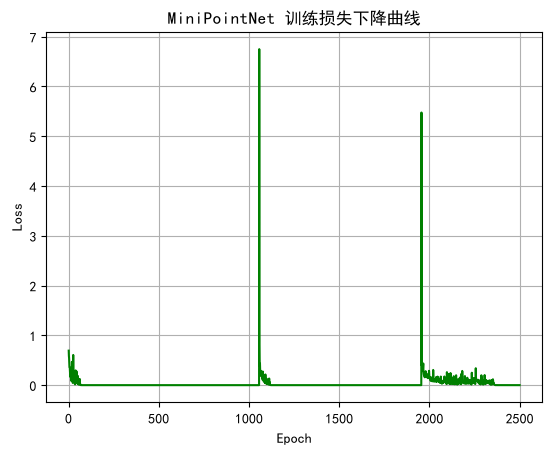

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_test=x_train.to(device),x_test.to(device)
y_train,y_test=y_train.to(device),y_test.to(device)
model=MiniPointNet().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)
loss_history=[]
epochs=2500
batch_size=32
for epoch in range(epochs):
    model.train()
    epoch_loss=0
    permutation=torch.randperm(x_train.size(0))
    for i in range(0,x_train.size(0),batch_size):
        indices=permutation[i:i+batch_size]
        batch_x,batch_y=x_train[indices],y_train[indices]
        outputs=model(batch_x)
        loss=criterion(outputs,batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss+=loss.item()
    avg_loss=epoch_loss/(x_train.size(0)//batch_size)
    loss_history.append(avg_loss)
   # print(f"Epoch[{epoch+1}/{epochs}],Loss:{avg_loss:.4f}")
model.eval()
with torch.no_grad():
    test_outputs=model(x_test)
    test_preds=torch.argmax(test_outputs,dim=1)
    accuracy=(test_preds==y_test).float().mean().item()
    print(f"\n accuracy on test set:{accuracy:.4f}")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.plot(range(1, epochs+1), loss_history, color='green')
plt.title("MiniPointNet 训练损失下降曲线")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()
